# **EE214 Machine Learning Basics and Practices**
## **Coding Task**





Below is a high-level Python skeleton that mirrors Part 2 requirements. Feel free to modify the
structure, but keep the same logical order so your work is easy for the graders to follow.

## **What is GAN?**
As we know, the key idea of **Generative Adversarial Networks (GANs)** is an *adversarial loss* that forces the generated fake images to be indistinguishable from real images. Also, GANs have achieved impressive results in Image-to-Image Translation tasks that converts an image from one
representation of a given scene, x, to another, y, e.g.,
grayscale to color, image to semantic labels, edge-map to
photograph.

In [1]:
import os, random
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.utils as vutils
import matplotlib.pyplot as plt
import torchvision.utils as vutils
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader
from PIL import Image
import numpy as np
import torch.nn.functional as fun # Renamed alias to avoid conflict

# Set random seed for reproducibility
############################## TODO ##############################
def set_seed(seed):
  torch.manual_seed(seed)
  torch.cuda.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)
  np.random.seed(seed)
  random.seed(seed)



  #I added this at end,so it may take longer to train the model if you are going to run the homework in your computer.
  #For the purpose of complete reproductibility
  torch.backends.cudnn.deterministic=True
  torch.backends.cudnn.benchmark=False


set_seed(42)

##################################################################

# Hyperparameters and configuration
batch_size = 64       # TODO: you can adjust this based on your GPU memory
image_size = 32     # 32x32 images
nz = 100            # Size of latent noise vector
ngf = 256           # Generator feature map size for first conv (number of filters)
ndf = 64
nc=3            # Discriminator base feature map size
num_epochs = 20     # Number of training epochs
lr = 0.0002         # Learning rate for Adam
beta1 = 0.5         # Beta1 hyperparameter for Adam optimizer

# Data preparation: CIFAR-10 training set and test set
############################## TODO ##############################
train_transformer=transforms.Compose([
    transforms.RandomHorizontalFlip(),
    #transforms.Resize(image_size),
    #transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])


test_transformer=transforms.Compose([
    #transforms.Resize(image_size),
    #transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

train_dataset=torchvision.datasets.CIFAR10(root='./data',train=True,download=True,transform=train_transformer)
test_dataset=torchvision.datasets.CIFAR10(root='./data',train=False,download=True,transform=test_transformer)

train_loader=DataLoader(train_dataset,batch_size=batch_size,shuffle=True,num_workers=2)
test_loader=DataLoader(test_dataset,batch_size=batch_size,shuffle=False,num_workers=2)
##################################################################

# Generator network: 100-dim noise to 3x32x32 image
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        ############################### TODO ##############################
        self.main = nn.Sequential(

            nn.ConvTranspose2d(nz, ngf*8, 4,1,0,bias=False),
            nn.BatchNorm2d(ngf*8),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf*8, ngf*4, 4,2,1,bias=False),
            nn.BatchNorm2d(ngf*4),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf*4, ngf*2, 4,2,1,bias=False),
            nn.BatchNorm2d(ngf*2),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf*2, nc ,4,2,1,bias=False),
            nn.Tanh()

        )


        ##################################################################

    def forward(self, x):

        return self.main(x)


# Discriminator network: 3x32x32 image to probability
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        ############################### TODO ##############################

        self.main = nn.Sequential(
            nn.Conv2d(3, ndf,4,2,1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 2, ndf *4,4,2,1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 4, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

        ###################################################################

    def forward(self, x):
        # Flatten the output to a scalar for each image
        out = self.main(x)
        return out.view(-1)  # flatten to shape (N,) or (N,1)

# Initialize the networks
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
netG = Generator().to(device)
netD = Discriminator().to(device)

# Apply DCGAN weight initialization to Conv and BatchNorm layers:contentReference[oaicite:27]{index=27}
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        # Initialize Conv and ConvTranspose weights
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    if classname.find('BatchNorm') != -1:
        # Initialize BatchNorm weight and bias
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

netG.apply(weights_init)
netD.apply(weights_init)

# Loss function and optimizers
criterion = nn.BCELoss()         # TODO
optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))       # TODO
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))      # TODO

# Create fixed noise for image sampling
fixed_noise = torch.randn(64, nz, 1, 1, device=device)

# Create output directory for sample images
os.makedirs("output_images", exist_ok=True)

# Training loop
print("Starting Training...")
for epoch in range(1, num_epochs+1):
    netG.train()  # set to train mode (enable grad, batchnorm updates)
    netD.train()
    running_loss_D = 0.0
    running_loss_G = 0.0
    for i, (real_images, _) in enumerate(train_loader):

        # (1) Train Discriminator D
        ############################## TODO ##############################
        real_images=real_images.to(device)
        b_size=real_images.size(0)

        netD.zero_grad()

        #Train with real images first

        labels_real=torch.ones(b_size, device=device)
        output_real=netD(real_images)
        loss_D_real=criterion(output_real,labels_real)
        loss_D_real.backward()

        #train with fake images
        noise=torch.randn(b_size,nz,1,1,device=device)
        fake_images=netG(noise)
        labels_fake=torch.zeros(b_size, device=device)
        output_fake=netD(fake_images.detach())
        loss_D_fake=criterion(output_fake, labels_fake)
        loss_D_fake.backward()

        loss_D=loss_D_fake + loss_D_real
        optimizerD.step()

        ##################################################################

        # (2) Train Generator G
        ############################## TODO ##############################
        netG.zero_grad()
        labels_real_for_G=torch.ones(b_size, device=device)
        output_fake_for_G=netD(fake_images)
        loss_G=criterion(output_fake_for_G,labels_real_for_G)
        loss_G.backward()
        optimizerG.step()

        running_loss_D+=loss_D.item()
        running_loss_G+=loss_G.item()

        ##################################################################

    # End of epoch: compute average losses
    ############################### TODO ##############################
    avg_loss_D=running_loss_D/len(train_loader)
    avg_loss_G=running_loss_G/len(train_loader)

    ###################################################################
    print(f"Epoch [{epoch}/{num_epochs}]  Loss_D: {avg_loss_D:.4f}  Loss_G: {avg_loss_G:.4f}")

    # Save sample images at epoch 1, mid (epoch 10), and final (epoch 20)
    if epoch in [1, 10, num_epochs]:
        netG.eval()  # eval mode for stable output (fix BatchNorm)
        with torch.no_grad():
            fake = netG(fixed_noise).detach().cpu()
        # Make a grid of 8x8 (64) images and save
        grid = vutils.make_grid(fake, nrow=8, normalize=True, value_range=(-1, 1))
        vutils.save_image(grid, f"output_images/epoch_{epoch}.png")
        netG.train()  # switch back to train for next epoch (if any)

print("Training complete!")

100%|██████████| 170M/170M [00:04<00:00, 41.7MB/s]


Starting Training...
Epoch [1/20]  Loss_D: 0.7408  Loss_G: 3.4944
Epoch [2/20]  Loss_D: 0.7501  Loss_G: 2.5923
Epoch [3/20]  Loss_D: 0.6783  Loss_G: 2.7090
Epoch [4/20]  Loss_D: 0.6953  Loss_G: 2.7062
Epoch [5/20]  Loss_D: 0.6799  Loss_G: 2.5594
Epoch [6/20]  Loss_D: 0.6652  Loss_G: 2.5694
Epoch [7/20]  Loss_D: 0.7628  Loss_G: 2.3642
Epoch [8/20]  Loss_D: 0.8124  Loss_G: 2.2409
Epoch [9/20]  Loss_D: 0.8573  Loss_G: 2.1050
Epoch [10/20]  Loss_D: 0.8202  Loss_G: 2.0962
Epoch [11/20]  Loss_D: 0.8990  Loss_G: 1.9913
Epoch [12/20]  Loss_D: 0.9510  Loss_G: 1.8583
Epoch [13/20]  Loss_D: 1.0041  Loss_G: 1.7888
Epoch [14/20]  Loss_D: 1.0152  Loss_G: 1.7278
Epoch [15/20]  Loss_D: 1.0404  Loss_G: 1.6870
Epoch [16/20]  Loss_D: 1.0474  Loss_G: 1.6765
Epoch [17/20]  Loss_D: 1.0836  Loss_G: 1.6085
Epoch [18/20]  Loss_D: 1.1081  Loss_G: 1.5806
Epoch [19/20]  Loss_D: 1.0951  Loss_G: 1.5663
Epoch [20/20]  Loss_D: 1.1166  Loss_G: 1.5532
Training complete!


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 33.0 MB/s eta 0:00:00


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 341MB/s]


Computing FID score...
Processing real images
Generating fake images...
Generated 8000/10000 images
Generated 10000/10000 images
FID score = 49.8362
(Lower FID is better - closer to 0 means generated images are more similar to real images)


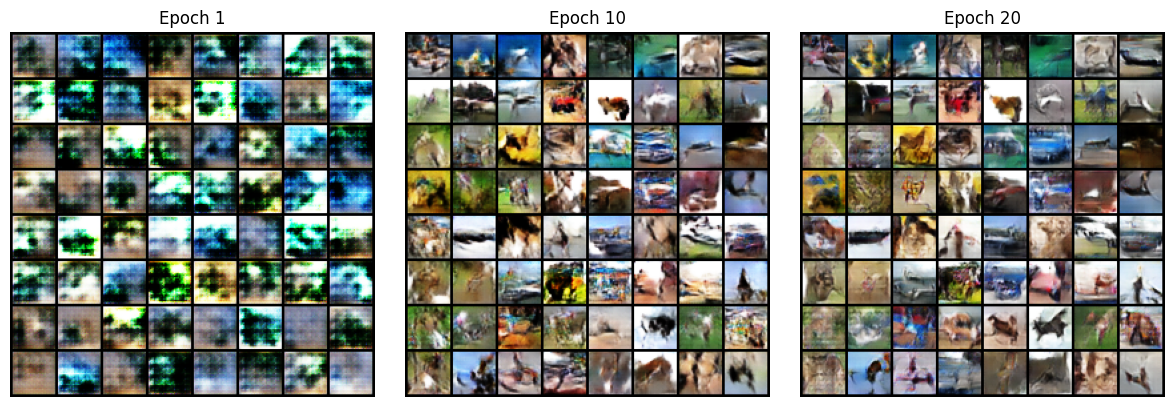

In [2]:
# Compute FID score using TorchMetrics (requires torchmetrics library)
!pip install torchmetrics[image]

try:
    from torchmetrics.image.fid import FrechetInceptionDistance
except ImportError:
    print("Please install torchmetrics (e.g., pip install torchmetrics[image]) to compute FID.")
    exit()

fid = FrechetInceptionDistance(feature=2048).to(device)  # feature dim 2048 for InceptionV3 pool3

# We accumulate real and fake features in the FID metric
netG.eval()  # eval mode for generator during FID computation

print("Computing FID score...")

print("Processing real images")
# Loop over real images from test set
for real_images, _ in test_loader:
    ############################### TODO ##############################
    real_images=real_images.to(device)
    real_images=(real_images+1)/2.0
    real_images = (real_images * 255).clamp(0, 255).to(torch.uint8)
    fid.update(real_images,real=True)

    ##################################################################
print("Generating fake images...")
num_real = len(test_dataset)  # 10000 for CIFAR-10 test
num_generated=0
# Loop to generate fake images (in baches) equal to the number of test images
############################### TODO ##############################
while num_generated < num_real:
  with torch.no_grad():
    current_batch_size=min(batch_size,num_real-num_generated)
    noise=torch.randn(current_batch_size,nz,1,1,device=device)
    fake_images=netG(noise)
    fake_images=(fake_images+1)/2.0
    fake_images = (fake_images * 255).clamp(0, 255).to(torch.uint8)
    fid.update(fake_images, real=False)

    num_generated+=current_batch_size

    if num_generated%1000==0:
      print(f"Generated {num_generated}/{num_real} images")

##################################################################

# Compute FID
fid_value = fid.compute()
print(f"FID score = {fid_value.item():.4f}")
print("(Lower FID is better - closer to 0 means generated images are more similar to real images)")
# Display saved generated images for visual inspection
def display_generated_images(image_dir="output_images", epochs=[1, 10, 20]):
    """
    Displays saved generated image grids from specific epochs for visual inspection.
    Assumes images are saved as PNG files like 'epoch_1.png' etc.
    """
    plt.figure(figsize=(12, 4))
    for i, epoch in enumerate(epochs):
        image_path = os.path.join(image_dir, f"epoch_{epoch}.png")
        if not os.path.exists(image_path):
            print(f"[!] Warning: {image_path} not found.")
            continue

        img = Image.open(image_path)
        plt.subplot(1, len(epochs), i+1)
        plt.imshow(img)
        plt.title(f"Epoch {epoch}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

display_generated_images()


## **What is CycleGAN?**
GANs have one practical problem that **obtaining paired training data can be difficult and expensive**(Figure 2(left)). For many tasks, like object transfiguration, the desired output is not even well-defined. Therefore, some methods that can learn to **translate between domains without paired input-output examples** are needed in Image-to-Image Translation tasks.

In the **CycleGan**, they present a method that can learn to do the
same: capturing special characteristics of one image collection
and figuring out how these characteristics could be
translated into the other image collection, all in the absence
of any paired training examples(Figure 2(right)) [1]. In particular, they exploit the property that translation should be **“cycle consistent”**, in the sense that if we translate,
e.g., a sentence from English to French, and then translate
it back from French to English, we should arrive back
at the original sentence. Their objective can be achieve by combining **cycle consistency loss with adversarial losses** on domains X and Y.

Please refer to the paper "*Unpaired image-to-image translation using cycle-consistent adversarial networks*" [1]. ([paper link](https://openaccess.thecvf.com/content_iccv_2017/html/Zhu_Unpaired_Image-To-Image_Translation_ICCV_2017_paper.html))

### **CycleGAN Formulation**
In this section, we formulate the CycleGAN based on the original paper ([paper link](https://openaccess.thecvf.com/content_iccv_2017/html/Zhu_Unpaired_Image-To-Image_Translation_ICCV_2017_paper.html)). As illustrated in Figure 3 (a), the model contains two mapping functions $G$ and $F$, and associated adversarial discriminators ${D_Y}$ and ${D_X}$ where
${D_X}$ aims to distinguish between real images from ${X}$ and translated
images ${F(Y)}$; in the same way, ${D_Y}$ aims to discriminate
between real images from ${Y}$ and ${G(X)}$. Here, ${X}$ and ${Y}$ represent two given domains.

### **1) Adversarial Loss**

Mapping $G : X \to Y$

$$
{L_{GAN}(G, D_Y, X, Y)} = \mathop{\mathbb{E}}_{y \sim p_{data}(y)}[\log D_{Y}(y)] + \mathop{\mathbb{E}}_{x \sim p_{data}(x)}[\log(1-D_{Y}(G(x)))] \tag{1}
$$

One of the loss functions is an *adversarial loss* for matching the distribution
of generated images to the data distribution in the target domain. First, for the mapping function $G : X \to Y$ and its discriminator
$D_Y$ , we can express the objective as equation (1) where $G$ tries to generate images $G(x)$ that look similar to
images from domain $Y$ , while $D_Y$ aims to distinguish between
translated samples $G(x)$ and real samples $y$. $G$ aims
to minimize this objective while discriminator $D$ tries to maximize it(equation (2)).

$$
\min_{G}\max_{D_Y}L_{GAN}(G, D_Y, X, Y) \tag{2}
$$

Similary, we can derive an adversarial loss for the mapping function $F : Y \to X$ and its discriminator $D_X$ like below equation (3) & (4).

Mapping $F : Y \to X$

$$
{L_{GAN}(F, D_X, Y, X)} = \mathop{\mathbb{E}}_{x \sim p_{data}(x)}[\log D_{X}(x)] + \mathop{\mathbb{E}}_{y \sim p_{data}(y)}[\log(1-
D_{X}(F(y)))] \tag{3}
$$

$$
\min_{F}\max_{D_X}L_{GAN}(F, D_X, Y, X) \tag{4}
$$



### **2) Cycle Consistency Loss**
The other term is a *cycle consistency loss* to prevent the learned mappings $G$ and $F$ from contradicting each other. In other words, the learned mapping functions should be cycle-consistent: **Forward cycle consistency & Backward cycle consistency**

1. **Forward cycle consistency**: As shown in Figure 3 (b), for each image $x$ from domain $X$, the image translation cycle should be able to bring $x$ back to the original image, i.e., $x \to G(x) \to F(G(x)) \to x$.
2. **Backward cycle consistency**: Similary, as shown in Figure 3 (c), for
each image y from domain Y , G and F should also satisfy backward cycle consistency: $y \to F(y) \to G(F(y)) \to y$.

Finally, we can derive a *cycle consistency loss* like equation (5) below and the behavior induced by the cycle consistency loss can be observed in Figure 4.

$${L_{cyc}(G, F)} = \mathop{\mathbb{E}}_{x \sim p_{data}(x)}[\|F(G(x))-x \|_1] + \mathop{\mathbb{E}}_{y \sim p_{data}(y)}[\|G(F(y))-y \|_1] \tag{5}$$


### **3) Full objective**
Finally, the full objective is:  

$$
L(G, F, D_X, D_Y) = L_{GAN}(G, D_Y, X, Y) + L_{GAN}(F, D_X, Y, X) + \lambda L_{cyc}(G, F), \tag{6}
$$

where $\lambda$ controls the relative importance of the two objectives.
And the solution we aim to optimize is:

$$
G^*, F^* = \arg \min_{G, F} \max_{D_X, D_Y} L(G, F, D_X, D_Y) \tag{7}
$$


---

## **CycleGAN Implementation using Pytorch**
In this section, we will **implement CycleGAN using Pytorch with MNIST and SVHN(Street View House Numbers) datasets**. Similar to MNIST dataset, the SVHN is a digit classification benchmark dataset that contains 600000 32×32 RGB images of printed digits (from 0 to 9) cropped from pictures of house number plates. Each dataset represents different domains and our goal is to translate between these two domains(see Figure below).







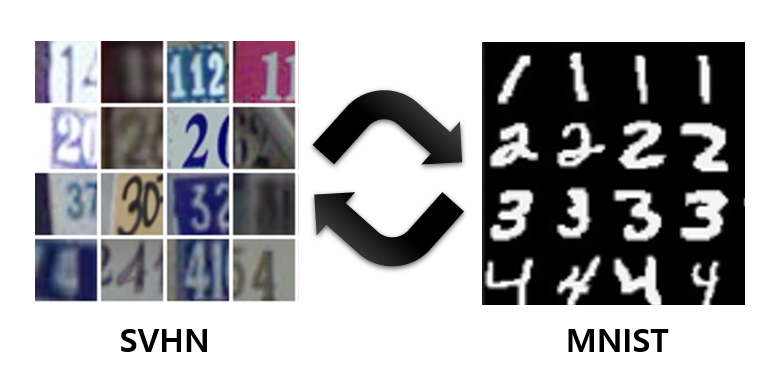

to be deleted

In [3]:
#Load the necessary modules & Set random seed for reproduction
import os
from torch.backends import cudnn
import torch
import numpy as np
import random
import torch.nn as nn
import cv2
from torch import optim
from torchvision import datasets
from torchvision import transforms
from google.colab.patches import cv2_imshow
from torch.nn.functional import cross_entropy, mse_loss

# Set random seed for reproducibility
############################## TODO ##############################
random_seed = 1
torch.manual_seed(random_seed)
torch.cuda.manual_seed(random_seed)
torch.cuda.manual_seed_all(random_seed) # for multi-GPU
np.random.seed(random_seed)
random.seed(random_seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


##################################################################

# Set hyper-parameters & Create directories if not exist.
# model hyper-parameters
image_size=32
g_conv_dim=64
d_conv_dim=64
use_labels=True
num_classes=10

# training hyper-parameters
train_iters=1000
batch_size=64
num_workers=2

lr=0.0002
betal=0.5
num_epochs=20
lambda_cycle=10
lambda_client=0.5

# misc
mode='train'
model_path='./models'
sample_path='./samples'
mnist_path='./mnist'
svhn_path='./svhn'
download=True


# create directories if not exist
if not os.path.exists(model_path):
    os.makedirs(model_path)
if not os.path.exists(sample_path):
    os.makedirs(sample_path)

# Define `get_loader()` function to transform data and build dataloader for MNIST and SVHN dataset, respectively. And then, we can make each dataloader iterable using `iter()` so that it can be used for train and test phase.
def get_loader():
    """Builds and returns Dataloader for MNIST and SVHN dataset."""
    ############################### TODO ##############################
    # Transform: Resize to 32, Convert to RGB, Normalize to [-1, 1]
    transform = transforms.Compose([
        transforms.Resize(image_size),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    # MNIST specifically needs 3 channels for this architecture
    mnist_transform = transforms.Compose([
        transforms.Resize(image_size),
        transforms.Grayscale(num_output_channels=1),
        transforms.ToTensor(),
        transforms.Normalize((0.5), (0.5))
    ])

    svhn = datasets.SVHN(root=svhn_path, split='train', download=True, transform=transform)
    mnist = datasets.MNIST(root=mnist_path, train=True, download=True, transform=mnist_transform)

    svhn_loader = DataLoader(dataset=svhn, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    mnist_loader = DataLoader(dataset=mnist, batch_size=batch_size, shuffle=True, num_workers=num_workers)


    ##################################################################
    return svhn_loader, mnist_loader


In [4]:
svhn_loader, mnist_loader = get_loader()
svhn_iter = iter(svhn_loader)
mnist_iter = iter(mnist_loader)
iter_per_epoch = min(len(svhn_loader), len(mnist_loader))

# fixed mnist and svhn for sampling

pretty_svhn = [0,1,8,9,12,13,20,21,
        24,25,26,27,28,29,34,35,38,39,
        43,49,50,54,55,58,59,65,66,68,
        69,70,71,74,80,83,84,87,88,89,
        90,91,95,96,97,98,99,102,103,104,
        105,106,107,108,109,110,111,112,113,114,
        115,127,128,129,133,134]

# Adjust fixed_svhn to load correctly (assuming it's already 3 channels)
# Get one batch of data from svhn_loader, which applies the transform
fixed_svhn_data, _ = next(svhn_iter)
fixed_svhn = fixed_svhn_data[0:batch_size].to(device)

# Adjust fixed_mnist to handle the single channel change and move to device
# Get one batch of data from mnist_loader, which applies the transform
fixed_mnist_data, _ = next(mnist_iter)
fixed_mnist = fixed_mnist_data[0:batch_size].to(device)

mnist_iter = iter(mnist_loader) # Reset iterator

100%|██████████| 182M/182M [00:01<00:00, 112MB/s]
100%|██████████| 9.91M/9.91M [00:00<00:00, 17.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 443kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.12MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.0MB/s]


**Define generator and discriminator**

- First, let's make the following residual block that will be used as an element of the generator.

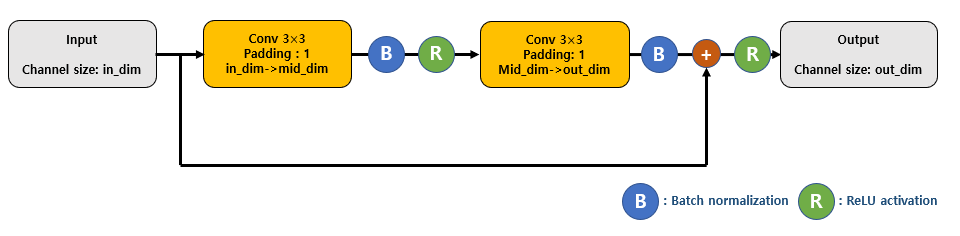

In [5]:
class Residual_Block(nn.Module):
    def __init__(self, in_dim, mid_dim, out_dim):
        super(Residual_Block, self).__init__()
        ########################### TODO ##############################
        self.block = nn.Sequential(
            nn.Conv2d(in_dim, mid_dim, kernel_size=3, stride=1, padding=1, bias=False),
            nn.InstanceNorm2d(mid_dim),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_dim, out_dim, kernel_size=3, stride=1, padding=1, bias=False),
            nn.InstanceNorm2d(out_dim)
        )

        ###############################################################

    def forward(self, x):
        ########################### TODO ##############################
        out = x + self.block(x)

        ###############################################################
        return out

In [6]:
#Based on residual block defined above, make a `Generator` class.

class Generator(nn.Module):
    def __init__(self, type, conv_dim=64):
        super(Generator, self).__init__()
        if type == 'mnist_to_svhn':
            in_dim, out_dim = 1, 3
        elif type == 'svhn_to_mnist':
            in_dim, out_dim = 3, 1

        # encoding blocks
        ########################### TODO ##############################
        # Layer 1: 32x32 -> 16x16
        self.enc1 = nn.Sequential(
            nn.Conv2d(in_dim, conv_dim, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(conv_dim),
            nn.ReLU(inplace=True)
        )
        # Layer 2: 16x16 -> 8x8
        self.enc2 = nn.Sequential(
            nn.Conv2d(conv_dim, conv_dim * 2, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(conv_dim * 2),
            nn.ReLU(inplace=True)
        )

        ###############################################################

        # residual blocks
        ########################### TODO ##############################
        # Bottleneck processing at 8x8 resolution
        self.res_blocks = nn.Sequential(
            Residual_Block(conv_dim * 2, conv_dim * 2, conv_dim * 2),
            Residual_Block(conv_dim * 2, conv_dim * 2, conv_dim * 2),
            Residual_Block(conv_dim * 2, conv_dim * 2, conv_dim * 2)
        )

        ###############################################################

        # decoding blocks
        ########################### TODO ##############################
        # Layer 1: 8x8 -> 16x16
        self.dec1 = nn.Sequential(
            nn.ConvTranspose2d(conv_dim * 2, conv_dim, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(conv_dim),
            nn.ReLU(inplace=True)
        )
        # Layer 2: 16x16 -> 32x32
        self.dec2 = nn.Sequential(
            nn.ConvTranspose2d(conv_dim, out_dim, 4, 2, 1, bias=False),
            nn.Tanh() # Scales output to [-1, 1]
        )

        ###############################################################

        # other layers
        ########################### TODO ##############################
        self.main = nn.Sequential(
            self.enc1,
            self.enc2,
            self.res_blocks,
            self.dec1,
            self.dec2
        )

        ###############################################################

    def forward(self, x):
        ########################### TODO ##############################
        out = self.main(x)

        ###############################################################
        return out

In [7]:
#`Discriminator` class which has a total of 11 classes (classes 0 through 9 are for real images and class 10 is for fake images).
class Discriminator(nn.Module):
    def __init__(self, type, conv_dim=64):
        super(Discriminator, self).__init__()
        if type == 'mnist':
            in_dim = 1
        elif type == 'svhn':
            in_dim = 3

        # learnable layers
        ############################### TODO ##############################
        # Input: 32x32 -> 16x16
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_dim, conv_dim, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True)
        )
        # 16x16 -> 8x8
        self.conv2 = nn.Sequential(
            nn.Conv2d(conv_dim, conv_dim * 2, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(conv_dim * 2),
            nn.LeakyReLU(0.2, inplace=True)
        )
        # 8x8 -> 4x4
        self.conv3 = nn.Sequential(
            nn.Conv2d(conv_dim * 2, conv_dim * 4, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(conv_dim * 4),
            nn.LeakyReLU(0.2, inplace=True)
        )
        # 4x4 -> 1x1
        self.conv4 = nn.Sequential(
            nn.Conv2d(conv_dim * 4, conv_dim * 2, 4, 1, 0, bias=False),
            nn.LeakyReLU(0.2, inplace=True)
        )

        ###############################################################

        # Note that classes 0 through 9 are for real images and class 10 is for fake images.
        self.fc = nn.Linear(conv_dim * 2, 11)

        # other functions
        ########################### TODO ##############################
        # All layers are defined as separate attributes, so no other 'main' sequential block is strictly needed in __init__ for this structure.
        # The forward method will call them sequentially.
        ###############################################################

    def forward(self, x):
        ########################### TODO ##############################
        out = self.conv1(x)
        out = self.conv2(out)
        out = self.conv3(out)
        out = self.conv4(out)
        # Reshape for the fully connected layer if needed, assuming conv4 output is 1x1
        out = out.view(out.size(0), -1)
        out = self.fc(out)
        ###############################################################
        return out

In [8]:
#Define the `optimize_model` function for optimizing networks
def optimize_model(optimizer, loss):
    ########################### TODO ##############################
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    ###############################################################

In [9]:
#Next, define some auxiliary functions that can be used to merge images, show log and save images: `merge_images()`, `show_log()`, `save_img()`.
def merge_images(sources, targets):
    _, _, h, w = sources.shape
    row = int(np.sqrt(batch_size))
    merged = np.zeros([3, row * h, row * w * 2])
    for idx, (s, t) in enumerate(zip(sources, targets)):
        i = idx // row
        j = idx % row
        merged[:, i * h:(i + 1) * h, (j * 2) * h:(j * 2 + 1) * h] = s
        merged[:, i * h:(i + 1) * h, (j * 2 + 1) * h:(j * 2 + 2) * h] = t
    return merged.transpose(1, 2, 0)


def show_log(step, train_iters, D_ms_losses, D_sm_losses, G_msm_losses, G_ses_losses):
    D_ms_avg = np.array(D_ms_losses).mean()
    D_sm_avg = np.array(D_sm_losses).mean()
    G_msm_avg = np.array(G_msm_losses).mean()
    G_sms_avg = np.array(G_ses_losses).mean()

    print('Step [%d/%d], D_ms_loss: %.4f, D_sm_loss: %.4f, G_msm_loss: %.4f, G_sms_loss: %.4f'
    % (step + 1, train_iters, D_ms_avg, D_sm_avg, G_msm_avg, G_sms_avg))


def save_img(step, fixed_mnist, fixed_svhn, G, F, m_data, s_data, sample_path):
    fake_svhn = G(fixed_mnist)
    fake_mnist = F(fixed_svhn)

    mnist, fake_mnist = fixed_mnist.detach().cpu().numpy(), fake_mnist.detach().cpu().numpy()
    svhn, fake_svhn = fixed_svhn.detach().cpu().numpy(), fake_svhn.detach().cpu().numpy()

    merged = merge_images(mnist, fake_svhn)
    merged = np.interp(merged, (-1, 1), (0, 255))
    path = os.path.join(sample_path, 'sample-%d-m-s.png' % (step + 1))
    cv2.imwrite(path, merged)
    print('saved %s' % path)

    merged = merge_images(svhn, fake_mnist)
    merged = np.interp(merged, (-1, 1), (0, 255))
    path = os.path.join(sample_path, 'sample-%d-s-m.png' % (step + 1))
    cv2.imwrite(path, merged)
    print('saved %s' % path)



> By using the functions we defined above, we can build two Generators($G, F$), two Discriminators($D_X, D_Y$) and optimizers. In this case, generator $G$ utilizes MNIST as source domain and SVHN as targer domain(and generator $F$, vice versa). And $D_X$ is a discriminator in the MNIST domain and $D_Y$ is a discriminator in the SVHN domain. Also, we take **Adam** as optimizer for both of generator and discriminator.



In [10]:
# Build models and their optimizers

# Generator
############################## TODO ##############################
G = Generator(type='mnist_to_svhn', conv_dim=g_conv_dim)
F = Generator(type='svhn_to_mnist', conv_dim=g_conv_dim)

# Move to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
G.to(device)
F.to(device)

##################################################################

# Discriminator
############################## TODO ##############################
D_X = Discriminator(type='mnist', conv_dim=d_conv_dim)
D_Y = Discriminator(type='svhn', conv_dim=d_conv_dim)

D_X.to(device)
D_Y.to(device)

##################################################################

# Set optimizers for generators and discriminators
############################## TODO ##############################
g_params = list(G.parameters()) + list(F.parameters())
g_optimizer = optim.Adam(g_params, lr=lr, betas=(beta1, 0.999))

# Combined discriminator parameters for joint update
d_params = list(D_X.parameters()) + list(D_Y.parameters())
d_optimizer = optim.Adam(d_params, lr=lr, betas=(beta1, 0.999))

##################################################################

**Train and evaluate CycleGAN**



Here define functions including `def Train_D_ms()`, `def Train_D_sm()`, `def Train_G_msm()`, `def Train_F_sms()`. For example, `def Train_D_ms()` is for training discriminators in **m**nist-**s**vhn cycle where the source $X$ is MNIST and the target $Y$ is SVHN dataset. And, `def Train_G_msm()` is for training generator G in **m**nist-**s**vhn-**m**nist cycle.






**Train discriminators (Dx, Dy)**



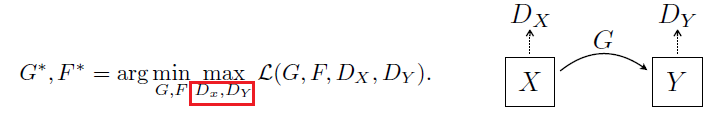

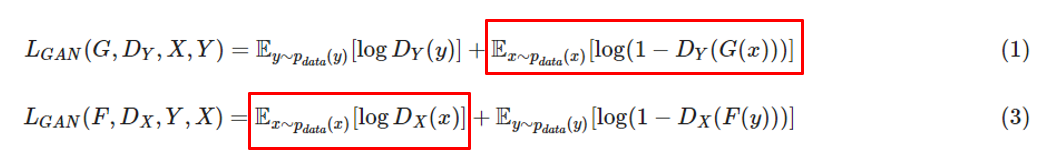


In [11]:
def Train_D_ms(Dx, Dy, G, m_data, m_label, d_optimizer):
    '''
    # parameter:
    Dx, Dy: Discriminator for source domain(X, MNIST) and target domain(Y, SVHN), respectively.
    G: Generator which transfers X to Y
    m_data: source domain data (i.e., MNIST real images)
    m_label: source domain label (from 0 to 9)

    Train two discriminators(Dx, Dy) in mnist-svhn cycle.
    Please refer to the above figure that represents the path from X to Y and equation (1),(3).
    Unlike the conventional GAN, here, the discriminator classifies 11 classes. You have to use 1) the original labels(from 0 to 9) when training the discriminator with real images, and 2) the fake label(10) when training the discriminator with fake(generated) images. You should make the fake label for training.
    So, "torch.nn.functional.cross_entropy()" will be used for calculating losses.


    Return:
    D_ms_loss.item(): item of the loss
    '''

    m_data = m_data.to(device)
    m_label = m_label.to(device)

    # train mnist-svhn cycle

    # 1) Compute the loss of Dx (Dx_loss) with real images
    ############################## TODO ##############################
    out_real = Dx(m_data)
    Dx_loss = torch.nn.functional.cross_entropy(out_real, m_label)

    ##################################################################

    # 2) Compute the loss of Dy (Dy_loss) with fake images
    ############################## TODO ##############################
    fake_svhn = G(m_data)

    fake_label = torch.full((m_data.size(0),), 10, dtype=torch.long).to(device)
    out_fake = Dy(fake_svhn.detach())
    Dy_loss = torch.nn.functional.cross_entropy(out_fake, fake_label)

    ##################################################################

    D_ms_loss = Dx_loss + Dy_loss
    optimize_model(d_optimizer, D_ms_loss)
    return D_ms_loss.item()

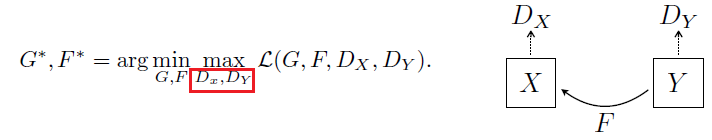

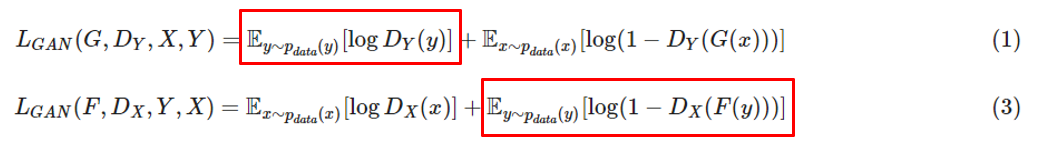

In [12]:
def Train_D_sm(Dx, Dy, F, s_data, s_label, d_optimizer):
    '''
    # parameter:
    Dx, Dy: Discriminator for source domain(X, MNIST) and target domain(Y, SVHN), respectively.
    F: Generator which transfers Y to X
    s_data: target domain data (i.e., SVHN real images)
    s_label: target domain label (from 0 to 9)

    Train discriminators in svhn-mnist cycle.
    Please refer to the above figure that represents the path from Y to X and equation (1),(3).
    Unlike the conventional GAN, here, the discriminator classifies 11 classes. You have to use 1) the original labels(from 0 to 9) when training the discriminator with real images, and 2) the fake label(10) when training the discriminator with fake(generated) images. You should make the fake label for training.
    So, "torch.nn.functional.cross_entropy()" will be used for calculating losses.

    Return:
    D_sm_loss.item(): item of the loss
    '''

    # train svhn-mnist cycle

    s_data = s_data.to(device)
    s_label = s_label.to(device)

    # 1) Compute the loss of Dy (Dy_loss) with real images
    ############################## TODO ##############################
    out_real_y = Dy(s_data)
    Dy_loss = torch.nn.functional.cross_entropy(out_real_y, s_label)

    ##################################################################

    # 2) Compute the loss of Dx (Dx_loss) with fake images
    ############################## TODO ##############################

    fake_mnist = F(s_data)

    fake_label = torch.full((s_data.size(0),), 10, dtype=torch.long).to(device)
    out_fake_x = Dx(fake_mnist.detach())
    Dx_loss = torch.nn.functional.cross_entropy(out_fake_x, fake_label)

    ##################################################################

    D_sm_loss = Dx_loss + Dy_loss
    optimize_model(d_optimizer, D_sm_loss)
    return D_sm_loss.item()

**Train generators (G, F) with cycle consistency loss**

> **1) Train the generator G**

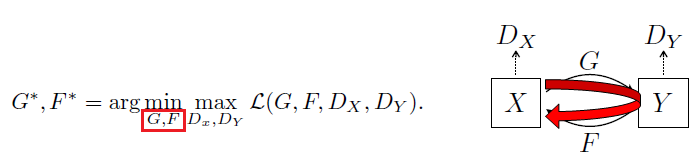

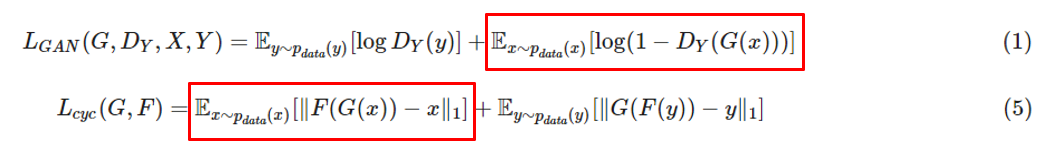

Note that, instead of L1 loss in equation (5), please use mean squared error loss $ \mathop{\mathbb{E}}_{x \sim p_{data}(x)}(F(G(x))-x)^2 $.

In [13]:
# train mnist-svhn-mnist cycle
def Train_G_msm(Dy, G, F, m_data, m_label, g_optimizer):
    '''
    # parameter:
    Dy: Discriminator for target domain(Y, SVHN).
    G, F: Generator for X to Y and Y to X.
    m_data: source domain data (i.e., MNIST real images)
    m_label: source domain label (from 0 to 9)

    Train mnist-svhn-mnist cycle.
    Please refer to the above figure that represents the path from X to Y to X and equation (1),(5).
    Note that you have to use original labels(from 0 to 9) when training the generator.
    So, "torch.nn.functional.cross_entropy()" will be used for calculating losses.
    Also, this function has to include cycle consistency loss(i.e. Lcyc) with mean squared error loss.

    Return:
    G_msm_loss.item(): item of the loss
    '''
    m_data = m_data.to(device)
    m_label = m_label.to(device)

    # 1) Compute the generator G loss (G_loss) with fake images
    ############################## TODO ##############################

    fake_svhn = G(m_data)
    out_fake = Dy(fake_svhn)

    G_loss = torch.nn.functional.cross_entropy(out_fake, m_label)

    ##################################################################

    # 2) Compute the cycle consistency loss (Lcyc)
    ############################## TODO ##############################

    reconstructed_mnist = F(fake_svhn)
    Lcyc = torch.nn.functional.mse_loss(reconstructed_mnist, m_data)


    ##################################################################

    G_msm_loss = G_loss + 100 * Lcyc
    optimize_model(g_optimizer, G_msm_loss)
    return G_msm_loss.item()

> **2) Train the generator F**

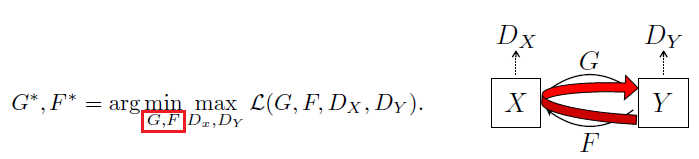

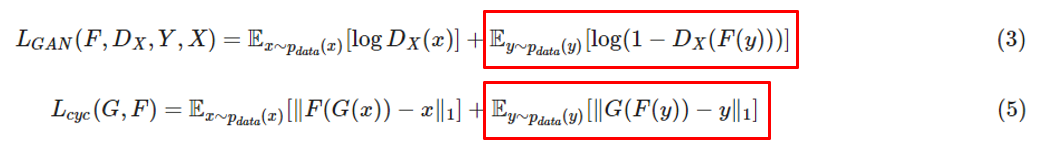

Note that, instead of L1 loss in equation (5), please use mean squared error loss $ \mathop{\mathbb{E}}_{y \sim p_{data}(y)}(G(F(y))-y)^2 $.

In [14]:
# train svhn-mnist-svhn cycle
def Train_G_sms(Dx, G, F, s_data, s_label, g_optimizer):
    '''
    # parameter: Dx: Discriminator for source domain(X, MNIST).
    # G, F: Generator for X to Y and Y to X.
    # s_data: target domain data (i.e., SVHN real images)
    # s_label: target domain label (from 0 to 9)

    # Train svhn-mnist-svhn cycle.
    # Please refer to the above figure that represents the path from Y to X to Y and equation (3),(5).
    # Note that you have to use original labels(from 0 to 9) when training the generator.
    # So, "torch.nn.functional.cross_entropy()" will be used for calculating losses.
    # Also, this function has to include cycle consistency loss(i.e. Lcyc) with mean squared error loss.

    # Return:
    # G_sms_loss.item(): item of the loss
    '''
    s_data = s_data.to(device)
    s_label = s_label.to(device)

    # 1) Compute the generator F loss (F_loss) with fake images
    ############################## TODO ##############################
    fake_mnist = F(s_data)
    out_fake = Dx(fake_mnist)

    F_loss = torch.nn.functional.cross_entropy(out_fake, s_label)

    ##################################################################

    # 2) Compute the cycle consistency loss (Lcyc)
    ############################## TODO ##############################
    reconstructed_svhn = G(fake_mnist)

    Lcyc = torch.nn.functional.mse_loss(reconstructed_svhn, s_data)

    ##################################################################

    G_sms_loss = F_loss + 100 * Lcyc
    optimize_model(g_optimizer, G_sms_loss)
    return G_sms_loss.item()

In [15]:
D_ms_losses, D_sm_losses, G_msm_losses, G_sms_losses = [], [], [], []

for step in range(train_iters + 1):
    # reset data_iter for each epoch
    if (step + 1) % iter_per_epoch == 0:
        mnist_iter = iter(mnist_loader)
        svhn_iter = iter(svhn_loader)

    # load svhn and mnist dataset
    s_data, s_label = next(svhn_iter)
    s_data, s_label = s_data.cuda(), s_label.cuda().long().squeeze()
    m_data, m_label = next(mnist_iter)
    m_data, m_label = m_data.cuda(), m_label.cuda()

    D_ms_losses.append(Train_D_ms(D_X, D_Y, G, m_data, m_label, d_optimizer))
    D_sm_losses.append(Train_D_sm(D_X, D_Y, F, s_data, s_label, d_optimizer))
    G_msm_losses.append(Train_G_msm(D_Y, G, F, m_data, m_label, g_optimizer))
    G_sms_losses.append(Train_G_sms(D_X, G, F, s_data, s_label, g_optimizer))

    # print the log info
    if (step + 1) % 100 == 0:
        show_log(step, train_iters, D_ms_losses, D_sm_losses, G_msm_losses, G_sms_losses)

    # save the sampled images
    if (step + 1) == 1000:
        save_img(step, fixed_mnist, fixed_svhn, G, F, m_data, s_data, sample_path)

Step [100/1000], D_ms_loss: 0.7586, D_sm_loss: 2.0658, G_msm_loss: 25.2773, G_sms_loss: 28.3447
Step [200/1000], D_ms_loss: 0.5946, D_sm_loss: 1.6775, G_msm_loss: 18.6948, G_sms_loss: 25.7594
Step [300/1000], D_ms_loss: 0.4949, D_sm_loss: 1.4287, G_msm_loss: 16.3049, G_sms_loss: 24.5544
Step [400/1000], D_ms_loss: 0.4425, D_sm_loss: 1.2891, G_msm_loss: 15.0083, G_sms_loss: 22.9087
Step [500/1000], D_ms_loss: 0.4061, D_sm_loss: 1.1919, G_msm_loss: 14.2763, G_sms_loss: 21.5313
Step [600/1000], D_ms_loss: 0.4001, D_sm_loss: 1.1364, G_msm_loss: 13.7376, G_sms_loss: 20.3482
Step [700/1000], D_ms_loss: 0.3880, D_sm_loss: 1.0971, G_msm_loss: 13.2965, G_sms_loss: 19.5124
Step [800/1000], D_ms_loss: 0.3829, D_sm_loss: 1.0540, G_msm_loss: 12.8283, G_sms_loss: 18.8584
Step [900/1000], D_ms_loss: 0.3756, D_sm_loss: 1.0326, G_msm_loss: 12.5312, G_sms_loss: 18.1538
Step [1000/1000], D_ms_loss: 0.3634, D_sm_loss: 0.9979, G_msm_loss: 12.2655, G_sms_loss: 17.5936
saved ./samples/sample-1000-m-s.png
sav

MNIST_to_SVHN


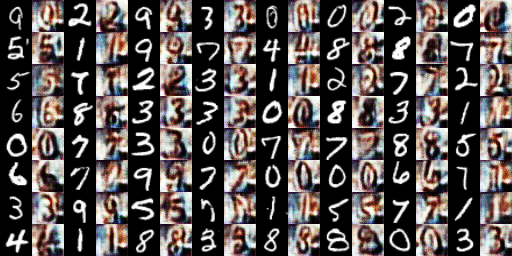

SVHN_to_MNIST


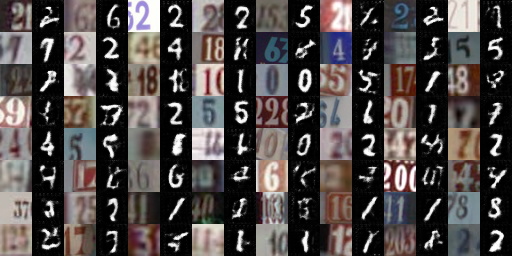

In [16]:
# Load and display the saved sample images
result_m_s = cv2.imread(os.path.join(sample_path, 'sample-1000-m-s.png'))       # TODO
result_s_m = cv2.imread(os.path.join(sample_path, 'sample-1000-s-m.png'))       # TODO

print('MNIST_to_SVHN')
cv2_imshow(result_m_s)

print('SVHN_to_MNIST')
cv2_imshow(result_s_m)